In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
from lightgbm import LGBMClassifier

In [ ]:
# Phase 1: Load + Aggregate Prev Loans
perf_url = "https://raw.githubusercontent.com/Oyeniran20/axia_cohort_8/main/trainperf.csv"
demo_url = "https://raw.githubusercontent.com/Oyeniran20/axia_cohort_8/main/traindemographics.csv"
prev_url = "https://raw.githubusercontent.com/Oyeniran20/axia_cohort_8/main/trainprevloans.csv"

perf = pd.read_csv(perf_url)
demo = pd.read_csv(demo_url)
prev = pd.read_csv(prev_url)

In [ ]:
perf.info()
demo.info()
prev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customerid     4368 non-null   object 
 1   systemloanid   4368 non-null   int64  
 2   loannumber     4368 non-null   int64  
 3   approveddate   4368 non-null   object 
 4   creationdate   4368 non-null   object 
 5   loanamount     4368 non-null   float64
 6   totaldue       4368 non-null   float64
 7   termdays       4368 non-null   int64  
 8   referredby     587 non-null    object 
 9   good_bad_flag  4368 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 341.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4346 entries, 0 to 4345
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customerid                  4346 non-null   object 
 1   birthdate          

In [ ]:
# Aggregate previous loans to 1 row/customer
prev_agg = prev.groupby("customerid").agg(
    prev_loan_count=("loannumber", "count"),
    avg_prev_loan_amount=("loanamount", "mean"),
    max_prev_loan_amount=("loanamount", "max"),
    total_prev_due=("totaldue", "sum"),
    missed_payment_events=("dayspastdue", lambda s: (s.fillna(0)>0).sum()) if "dayspastdue" in prev.columns else ("loannumber","count")
).reset_index()

# Merge into one modeling frame
df = perf.merge(demo, on="customerid", how="left") \
         .merge(prev_agg, on="customerid", how="left")

In [ ]:
# PHASE 2 – Data Preparation & Exploration
#2.1 Basic cleaning ----
df = df.drop_duplicates().copy()

# let me try and Parse dates and create age
if "birthdate" in df.columns:
    df["birthdate"] = pd.to_datetime(df["birthdate"], errors="coerce")
if "approveddate" in df.columns:
    df["approveddate"] = pd.to_datetime(df["approveddate"], errors="coerce")
if "creationdate" in df.columns:
    df["creationdate"] = pd.to_datetime(df["creationdate"], errors="coerce")

#  2.2 Handle missing values (mode/median)
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_all = df.select_dtypes(exclude=[np.number]).columns.tolist()

for c in num_cols_all:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

for c in cat_cols_all:
    df[c] = df[c].fillna(df[c].mode().iloc[0])

In [ ]:
df

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,...,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients,prev_loan_count,avg_prev_loan_amount,max_prev_loan_amount,total_prev_due,missed_payment_events
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56,2017-07-25 07:22:47,30000.0,34500.0,30,8a858fc55b2548dd015b286e452c678c,Good,...,6.433055,Diamond Bank,OGBA,Permanent,Post-Graduate,11.0,18181.818182,30000.0,242900.0,11.0
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41,2017-07-05 16:04:18,15000.0,17250.0,30,8a858fc55b2548dd015b286e452c678c,Good,...,7.320700,GT Bank,"DUGBE,IBADAN",Permanent,Graduate,3.0,10000.000000,10000.0,36000.0,3.0
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57,2017-07-06 13:52:51,20000.0,22250.0,15,8a858fc55b2548dd015b286e452c678c,Good,...,10.292041,EcoBank,OGBA,Permanent,Graduate,6.0,10000.000000,10000.0,70500.0,6.0
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41,2017-07-27 18:00:35,10000.0,11500.0,15,8a858fc55b2548dd015b286e452c678c,Good,...,7.491708,First Bank,OGBA,Permanent,Graduate,2.0,10000.000000,10000.0,24500.0,2.0
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45,2017-07-03 22:42:39,40000.0,44000.0,30,8a858fc55b2548dd015b286e452c678c,Good,...,9.076574,GT Bank,OGBA,Permanent,Primary,8.0,18750.000000,30000.0,188400.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4371,8a858e6d58b0cc520158beeb14b22a5a,302003163,2,2017-07-30 09:19:42,2017-07-30 08:18:30,10000.0,13000.0,30,8a858fc55b2548dd015b286e452c678c,Bad,...,6.625681,GT Bank,OGBA,Permanent,Graduate,1.0,10000.000000,10000.0,13000.0,1.0
4372,8a858ee85cf400f5015cf44ab1c42d5c,301998967,2,2017-07-27 15:35:47,2017-07-27 14:35:40,10000.0,13000.0,30,8a858fc55b2548dd015b286e452c678c,Bad,...,8.460608,FCMB,OGBA,Permanent,Graduate,1.0,10000.000000,10000.0,13000.0,1.0
4373,8a858f365b2547f3015b284597147c94,301995576,3,2017-07-25 16:25:57,2017-07-25 15:24:47,10000.0,11500.0,15,8a858fc55b2548dd015b286e452c678c,Bad,...,7.409129,First Bank,OGBA,Permanent,Graduate,2.0,10000.000000,10000.0,23000.0,2.0
4374,8a858f935ca09667015ca0ee3bc63f51,301977679,2,2017-07-14 13:50:27,2017-07-14 12:50:21,10000.0,13000.0,30,8a858eda5c8863ff015c9dead65807bb,Bad,...,7.386796,Skye Bank,OGBA,Permanent,Graduate,1.0,10000.000000,10000.0,13000.0,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4368 entries, 0 to 4375
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customerid                  4368 non-null   object        
 1   systemloanid                4368 non-null   int64         
 2   loannumber                  4368 non-null   int64         
 3   approveddate                4368 non-null   datetime64[ns]
 4   creationdate                4368 non-null   datetime64[ns]
 5   loanamount                  4368 non-null   float64       
 6   totaldue                    4368 non-null   float64       
 7   termdays                    4368 non-null   int64         
 8   referredby                  4368 non-null   object        
 9   good_bad_flag               4368 non-null   object        
 10  birthdate                   4368 non-null   datetime64[ns]
 11  bank_account_type           4368 non-null   object        
 1

In [ ]:
# Phase 2.3 Feature Engineering
# Loan to income ratio
if "loanamount" in df.columns and "monthlyincome" in df.columns:
    df["loan_to_income_ratio"] = df["loanamount"] / (df["monthlyincome"]+1e-6)

# Risk band from credit score
if "creditscore" in df.columns:
    df["risk_band"] = pd.cut(df["creditscore"],
                             bins=[300,580,670,740,800,850],
                             labels=["Poor","Fair","Good","Very Good","Excellent"])

# Payment behavior score
if "missedpayment" in df.columns and "dayspastdue" in df.columns:
    df["payment_behavior_score"] = df["missedpayment"]*2 + (df["dayspastdue"]>30).astype(int)

print("Feature engineering complete")


Feature engineering complete


<Figure size 1200x800 with 0 Axes>

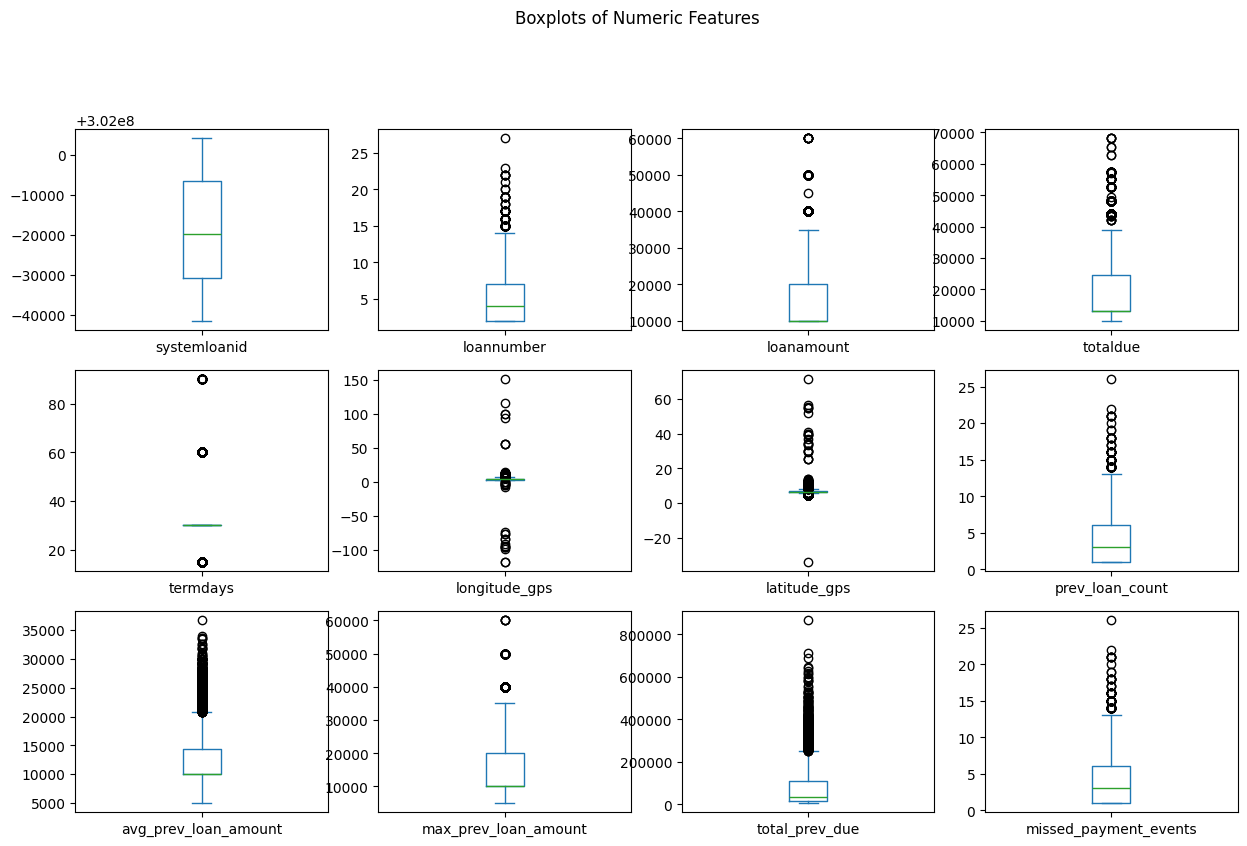

In [ ]:
# Phase 2.4 EDA (Plots)
# Boxplot of numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12,8))
df[num_cols].plot(kind="box", subplots=True, layout=(4,4), figsize=(15,12))
plt.suptitle("Boxplots of Numeric Features")
plt.show()

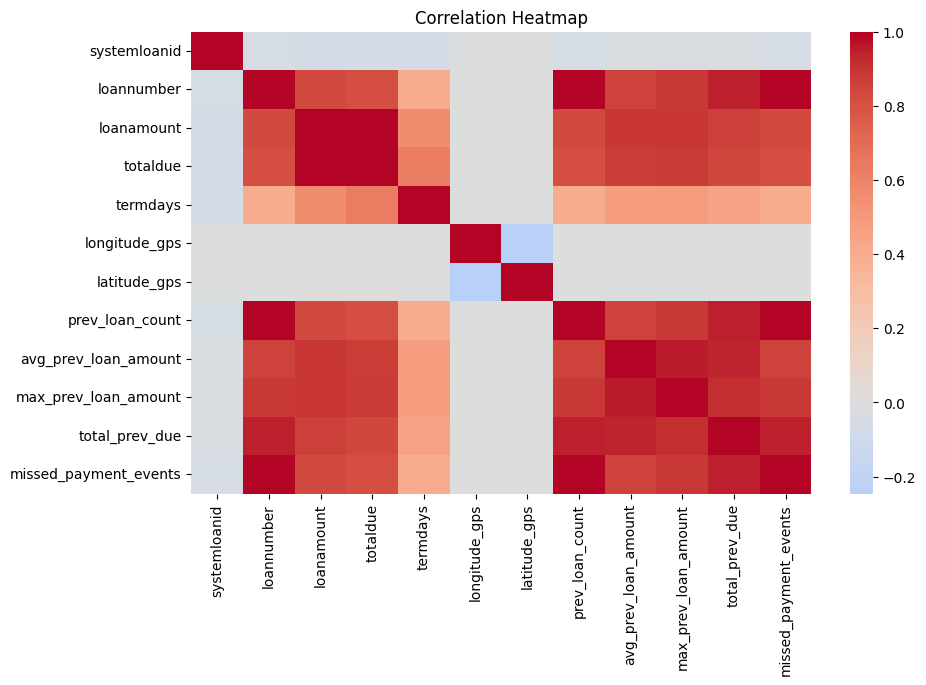

In [ ]:
# Correlation heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Phase 3: Robust Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import OneHotEncoder

target = "good_bad_flag"
df[target] = df[target].apply(lambda x: 1 if x == 'Good' else 0)

y = df[target]
X = df.drop(columns=[target,"customerid"])

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

num_tf = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
cat_tf = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                   ("onehot", OneHotEncoder(handle_unknown="ignore"))])
pre = ColumnTransformer([("num", num_tf, num_cols),
                         ("cat", cat_tf, cat_cols)])

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

models = {
    "Logistic": LogisticRegression(max_iter=500,class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=300,class_weight="balanced_subsample",random_state=42),
    "XGBoost": XGBClassifier(n_estimators=500,learning_rate=0.05,max_depth=5,random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=500,learning_rate=0.05,random_state=42)
}

results = []
for name,clf in models.items():
    pipe = ImbPipeline([("pre",pre),("smote",SMOTE(random_state=42)),("clf",clf)])
    cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
    aucs=[]
    for train_idx,val_idx in cv.split(X_train,y_train):
        pipe.fit(X_train.iloc[train_idx],y_train.iloc[train_idx])
        proba = pipe.predict_proba(X_train.iloc[val_idx])[:,1]
        aucs.append(roc_auc_score(y_train.iloc[val_idx],proba))
    avg_auc = np.mean(aucs)

    pipe.fit(X_train,y_train)
    proba_test = pipe.predict_proba(X_test)[:,1]
    preds = (proba_test>=0.5).astype(int)

    metrics = {
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test,proba_test),
        "Accuracy": accuracy_score(y_test,preds),
        "Precision": precision_score(y_test,preds),
        "Recall": recall_score(y_test,preds),
        "F1": f1_score(y_test,preds)
    }
    results.append(metrics)
    print(f"\n{name} Metrics:",metrics)
    print(classification_report(y_test,preds))

results_df = pd.DataFrame(results)
print("\nModel Comparison:\n",results_df)


Logistic Metrics: {'Model': 'Logistic', 'ROC_AUC': np.float64(0.5972760849492151), 'Accuracy': 0.7597254004576659, 'Precision': 0.7801418439716312, 'Recall': 0.9649122807017544, 'F1': 0.8627450980392157}
              precision    recall  f1-score   support

           0       0.14      0.02      0.04       190
           1       0.78      0.96      0.86       684

    accuracy                           0.76       874
   macro avg       0.46      0.49      0.45       874
weighted avg       0.64      0.76      0.68       874


RandomForest Metrics: {'Model': 'RandomForest', 'ROC_AUC': np.float64(0.573149430594029), 'Accuracy': 0.782608695652174, 'Precision': 0.783256880733945, 'Recall': 0.9985380116959064, 'F1': 0.877892030848329}
              precision    recall  f1-score   support

           0       0.50      0.01      0.01       190
           1       0.78      1.00      0.88       684

    accuracy                           0.78       874
   macro avg       0.64      0.50      0.

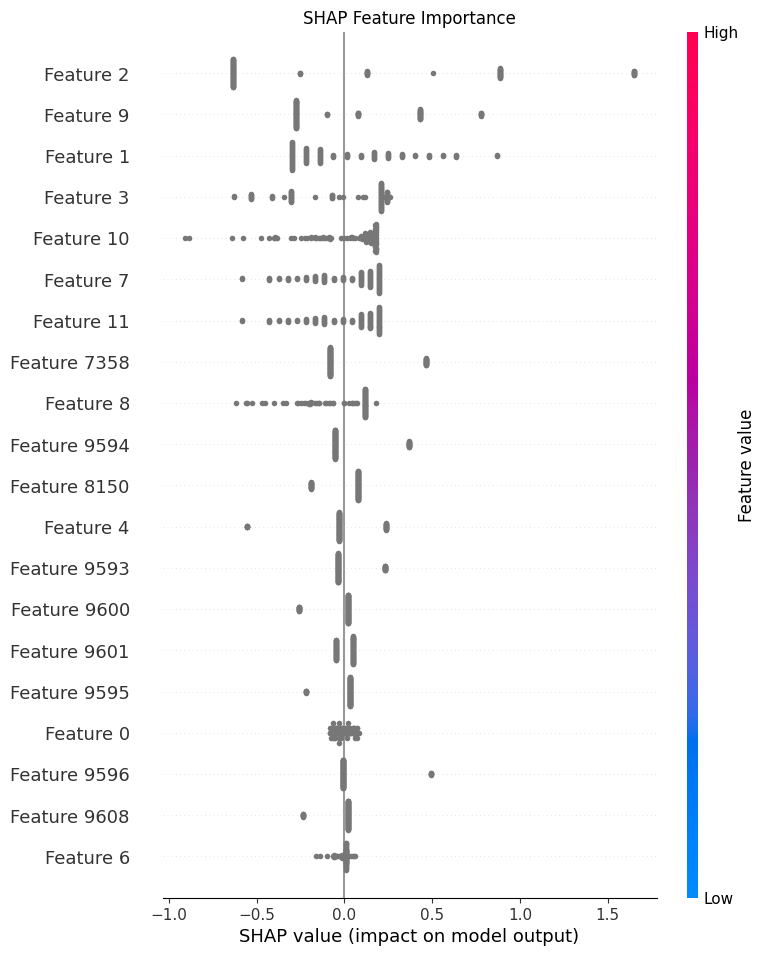

In [ ]:
# Phase 3.1 SHAP Explainability
import shap

best_model_name = results_df.sort_values("ROC_AUC",ascending=False).iloc[0]["Model"]
best_clf = models[best_model_name]
final_pipe = ImbPipeline([("pre",pre),("smote",SMOTE(random_state=42)),("clf",best_clf)])
final_pipe.fit(X_train,y_train)

explainer = shap.Explainer(final_pipe.named_steps["clf"],
                           final_pipe.named_steps["pre"].transform(X_train))
shap_values = explainer(final_pipe.named_steps["pre"].transform(X_test[:100]))
shap.summary_plot(shap_values,show=False)
plt.title("SHAP Feature Importance")
plt.show()

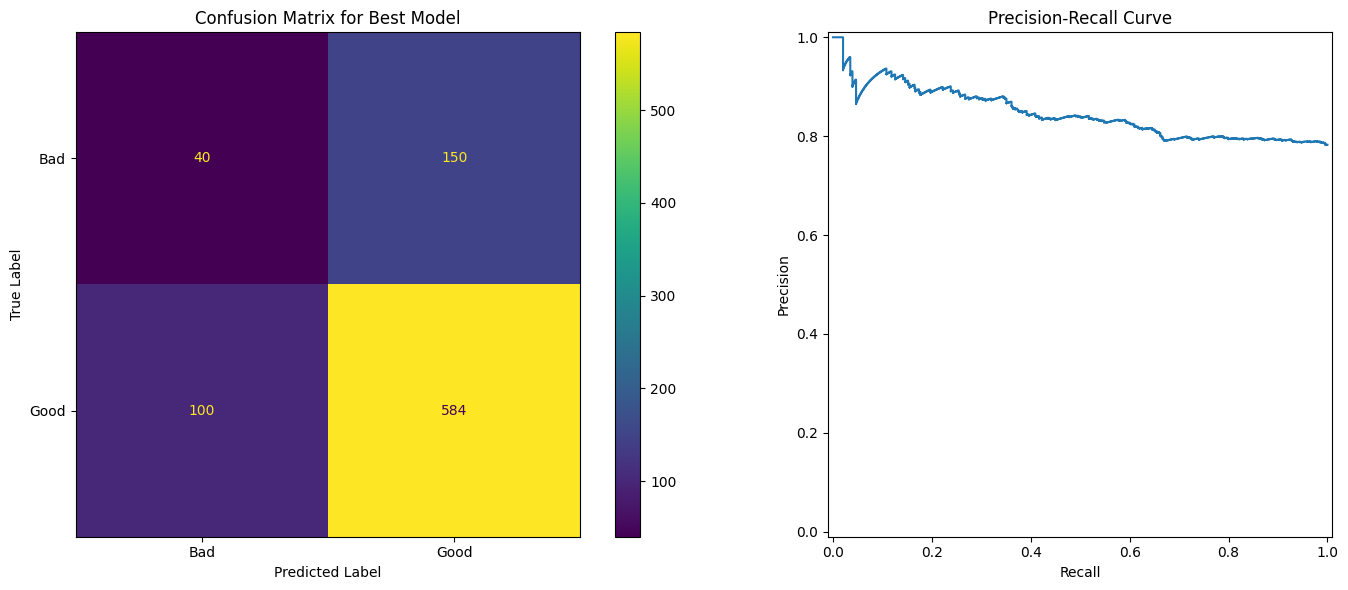


Analysis of Confusion Matrix and Precision-Recall Curve:
Confusion Matrix:
[[ 40 150]
 [100 584]]

Interpretation of Confusion Matrix:
- True Positives (TP): 584 (Correctly predicted 'Good' loans)
- True Negatives (TN): 40 (Correctly predicted 'Bad' loans)
- False Positives (FP): 150 (Incorrectly predicted 'Good' loans - Type I error)
- False Negatives (FN): 100 (Incorrectly predicted 'Bad' loans - Type II error)

Interpretation of Precision-Recall Curve:
The Precision-Recall curve shows the trade-off between Precision and Recall for different probability thresholds.
Precision is the ability of the classifier not to label as positive a sample that is negative (TP / (TP + FP)).
Recall is the ability of the classifier to find all the positive samples (TP / (TP + FN)).
A higher curve generally indicates better performance, especially for the minority class ('Bad' loans, which is class 0 in this case).
The shape of the curve indicates how precision changes as recall increases.
A rapid dro

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, preds)

# Plot confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bad', 'Good']).plot(ax=ax[0])
ax[0].set_title("Confusion Matrix for Best Model")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

# Calculate precision-recall curve
precision, recall, _ = precision_recall_curve(y_test, proba_test)

# Plot precision-recall curve
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot(ax=ax[1])
ax[1].set_title("Precision-Recall Curve")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")

plt.tight_layout()
plt.show()

# Analyze the results (manual analysis based on the generated plots)
print("\nAnalysis of Confusion Matrix and Precision-Recall Curve:")
print("Confusion Matrix:")
print(cm)
print("\nInterpretation of Confusion Matrix:")
print(f"- True Positives (TP): {cm[1, 1]} (Correctly predicted 'Good' loans)")
print(f"- True Negatives (TN): {cm[0, 0]} (Correctly predicted 'Bad' loans)")
print(f"- False Positives (FP): {cm[0, 1]} (Incorrectly predicted 'Good' loans - Type I error)")
print(f"- False Negatives (FN): {cm[1, 0]} (Incorrectly predicted 'Bad' loans - Type II error)")

print("\nInterpretation of Precision-Recall Curve:")
print("The Precision-Recall curve shows the trade-off between Precision and Recall for different probability thresholds.")
print("Precision is the ability of the classifier not to label as positive a sample that is negative (TP / (TP + FP)).")
print("Recall is the ability of the classifier to find all the positive samples (TP / (TP + FN)).")
print("A higher curve generally indicates better performance, especially for the minority class ('Bad' loans, which is class 0 in this case).")
print("The shape of the curve indicates how precision changes as recall increases.")
print("A rapid drop in precision as recall increases suggests that the model has difficulty identifying positive instances without also increasing the number of false positives.")

In [ ]:
# Phase 4: Threshold Optimization (Cost-sensitive)
from sklearn.metrics import confusion_matrix

# Example costs: FN (missed bad loan) is 5x worse than FP (rejecting good loan)
COST_FN = 5
COST_FP = 1

proba = proba_test
thresholds = np.linspace(0.1,0.9,81)
best_thr, best_cost = 0.5, float("inf")

for thr in thresholds:
    preds_thr = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_thr).ravel()
    cost = fp*COST_FP + fn*COST_FN
    if cost < best_cost:
        best_cost, best_thr = cost, thr

print(f"\nOptimal Threshold: {best_thr:.2f} (Minimized Expected Cost={best_cost})")


Optimal Threshold: 0.11 (Minimized Expected Cost=202)


In [ ]:
# Phase 5: Save Results for Power BI
os.makedirs("artifacts", exist_ok=True)

# Save scored test set with optimized threshold
preds_opt = (proba >= best_thr).astype(int)
scored = X_test.copy()
scored["actual"] = y_test.values
scored["score"] = proba
scored["prediction"] = preds_opt
scored.to_csv("artifacts/scored_test.csv", index=False)

# Cohort default rates (e.g., by risk_band or loan_purpose)
if "risk_band" in df.columns:
    cohort = scored.copy()
    cohort["risk_band"] = X_test["risk_band"].values
    cohort_rates = cohort.groupby("risk_band").agg(
        records=("actual","size"),
        default_rate=("actual","mean"),
        avg_score=("score","mean")
    ).reset_index()
    cohort_rates.to_csv("artifacts/cohort_rates.csv", index=False)

print("\nSaved Power BI CSVs: scored_test.csv and cohort_rates.csv")

from google.colab import files
files.download("artifacts/scored_test.csv")



Saved Power BI CSVs: scored_test.csv and cohort_rates.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Reasoning**:
Save the trained pipeline to a file for later use.



In [ ]:
import joblib

joblib.dump(final_pipe, "artifacts/full_pipeline.joblib")
print("\nSaved full pipeline: full_pipeline.joblib")


Saved full pipeline: full_pipeline.joblib


In [ ]:
loaded_pipeline = joblib.load("artifacts/full_pipeline.joblib")
print("Pipeline loaded successfully.")

Pipeline loaded successfully.


**Reasoning**:
Use the loaded pipeline to make predictions on the test set and apply the optimal threshold.



In [ ]:
# Use the loaded pipeline to make predictions
proba_loaded = loaded_pipeline.predict_proba(X_test)[:, 1]

# Apply the optimal threshold
preds_loaded_opt = (proba_loaded >= best_thr).astype(int)

# Print the first 10 predicted probabilities and binary predictions
print("First 10 predicted probabilities from loaded pipeline:", proba_loaded[:10])
print("First 10 binary predictions from loaded pipeline (optimal threshold):", preds_loaded_opt[:10])

First 10 predicted probabilities from loaded pipeline: [0.54820271 0.77568486 0.51497449 0.63851809 0.57971467 0.60089646
 0.8332793  0.91308666 0.76538875 0.70310942]
First 10 binary predictions from loaded pipeline (optimal threshold): [1 1 1 1 1 1 1 1 1 1]


In [ ]:
# Cohort summaries for BI (employment × education)
cohort = scored.copy()
cohort["employment_status_clients"] = X_test["employment_status_clients"].values
cohort["level_of_education_clients"] = X_test["level_of_education_clients"].values
(
    cohort.groupby(["employment_status_clients","level_of_education_clients"])
          .agg(records=("actual","size"),
               default_rate=("actual","mean"),
               avg_score=("score","mean"))
          .reset_index()
).to_csv("artifacts/cohort_employment_education.csv", index=False)

# Decile export for lift chart (if you prefer precomputed deciles)
cohort["score_decile"] = pd.qcut(cohort["score"], 10, labels=False, duplicates="drop")+1
decile = (
    cohort.groupby("score_decile")
          .agg(records=("actual","size"),
               positives=("actual","sum"),
               avg_score=("score","mean"))
          .reset_index()
)
decile["cum_positives_pct"] = decile["positives"].cumsum()/decile["positives"].sum()
decile["cum_population_pct"] = decile["records"].cumsum()/decile["records"].sum()
decile["lift"] = decile["cum_positives_pct"]/decile["cum_population_pct"]
decile.to_csv("artifacts/deciles.csv", index=False)
